### Project Title: Diabetes Prediction Web App
Prepared By:
- Name: Abhishek Sahu
- Domain: Data Science
- ID : CT_CSI_DS_5981
  
The goal of this project is to develop an interactive web application that deploys a trained machine learning model to predict the likelihood of diabetes in patients based on diagnostic health parameters.

This app will enable users to input relevant medical data, receive real-time predictions, and understand the model’s behavior through intuitive visualizations.

#### Dataset Used
Source: Pima Indians Diabetes Dataset (Kaggle/UCI)

Features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

#### About the Dataset

This dataset is originally from the **National Institute of Diabetes and Digestive and Kidney Diseases**. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are **females at least 21 years old of Pima Indian heritage**.

The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

Dataset Link : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

### Diabetes Dataset Metadata
This dataset is used to predict whether a patient has diabetes based on diagnostic measurements. It is derived from the Pima Indians Diabetes Database, a well-known machine learning benchmark dataset.

Observations: ~768 samples (in typical versions)

Features: 8 input features + 1 target

#### Columns

| Feature                      | Type      | Description                                   |
| ---------------------------- | --------- | --------------------------------------------- |
| **Pregnancies**              | int       | Number of times pregnant                      |
| **Glucose**                  | int       | Plasma glucose concentration                  |
| **BloodPressure**            | int       | Diastolic blood pressure (mm Hg)              |
| **SkinThickness**            | int       | Triceps skinfold thickness (mm)               |
| **Insulin**                  | int       | 2-Hour serum insulin (mu U/ml)                |
| **BMI**                      | float     | Body mass index (weight in kg/(height)^2)     |
| **DiabetesPedigreeFunction** | float     | Diabetes pedigree function                    |
| **Age**                      | int       | Age (years)                                   |
| **Outcome**                  | int (0/1) | Class variable (0: non-diabetic, 1: diabetic) |

#### Target Variable
Outcome = 0: Not diabetic

Outcome = 1: Diabetic

### Expected Outcomes
- A deployed web app where healthcare practitioners, students, or patients can input diagnostic data and get instant predictions.

- Enhanced interpretability through visualization of:

- Prediction confidence

- Feature importance scores


### Importing Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import plotly.express as px
#import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [61]:
df = pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week7_Task\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Data profiling

In [3]:
# showing first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# showing last 5 rows
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
# Showing dimensions of the dataset
df.shape

(768, 9)

In [6]:
# showing column names
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
# checking for data types
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [9]:
# showing information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


From the above information we can conclude that

1. The dataset has 768 rows and 9 columns.
2. The dataset has no null values.
3. All the columns of the dataset are of numerical type.

In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Data Cleaning and Preprocessing

#### Handling Duplicates

In [3]:
# checking for duplicated values
df.duplicated().sum()

0

#### Handling Missing Values

In [4]:
# checking for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### Descriptive Statistical Analysis

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Outliers Detection

#### Checking for No. of Outliers in each column and removing

In [6]:
# Checking for outliers using IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print('Outliers count of each column')
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Outliers count of each column
Pregnancies                  4
Glucose                      5
BloodPressure               45
SkinThickness                1
Insulin                     34
BMI                         19
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64


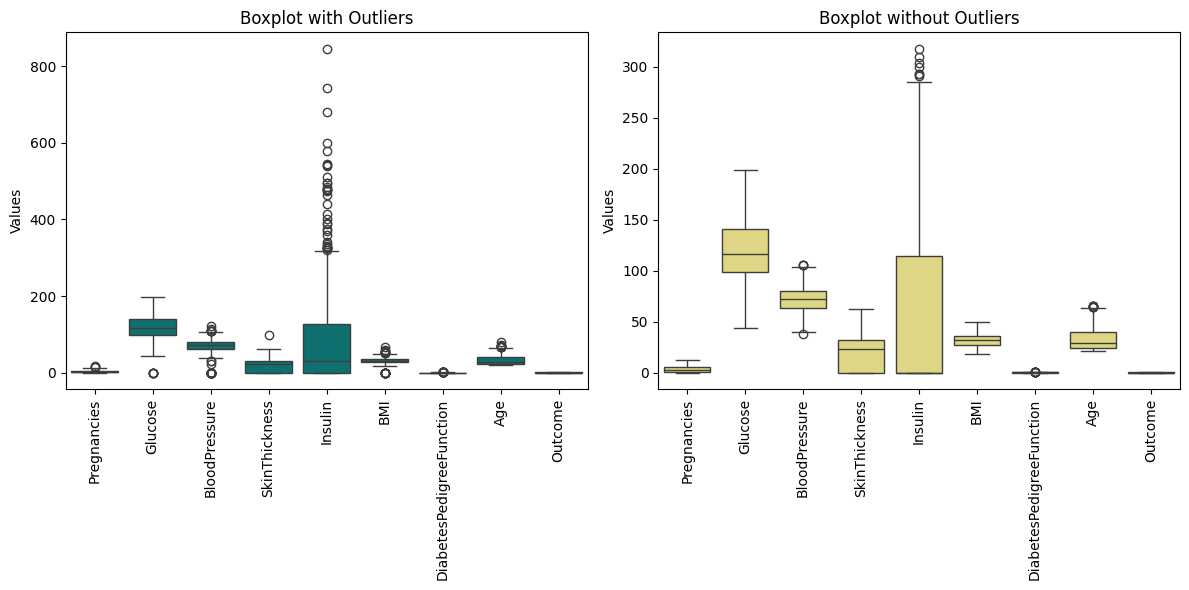

In [7]:
# Calculate Q1, Q3, and IQR for each column in the diabetes dataset
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Find outliers in each column
outliers_mask = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

# Create a DataFrame to store the outliers information
outliers_df = pd.DataFrame(outliers_mask, columns=df.columns)

# Remove outliers from each column
diabetes_no_outliers = df[~outliers_mask]

# Plot boxplots for both datasets (with and without outliers) side by side using seaborn
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, color="#008080")
plt.title("Boxplot with Outliers")
plt.ylabel("Values")
plt.xticks(rotation=90)

plt.subplot(1, 2, 2)
sns.boxplot(data=diabetes_no_outliers, color="#EDE275")
plt.title("Boxplot without Outliers")
plt.ylabel("Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Outliers Removed

### Data Visualization

#### Plotting Histplot

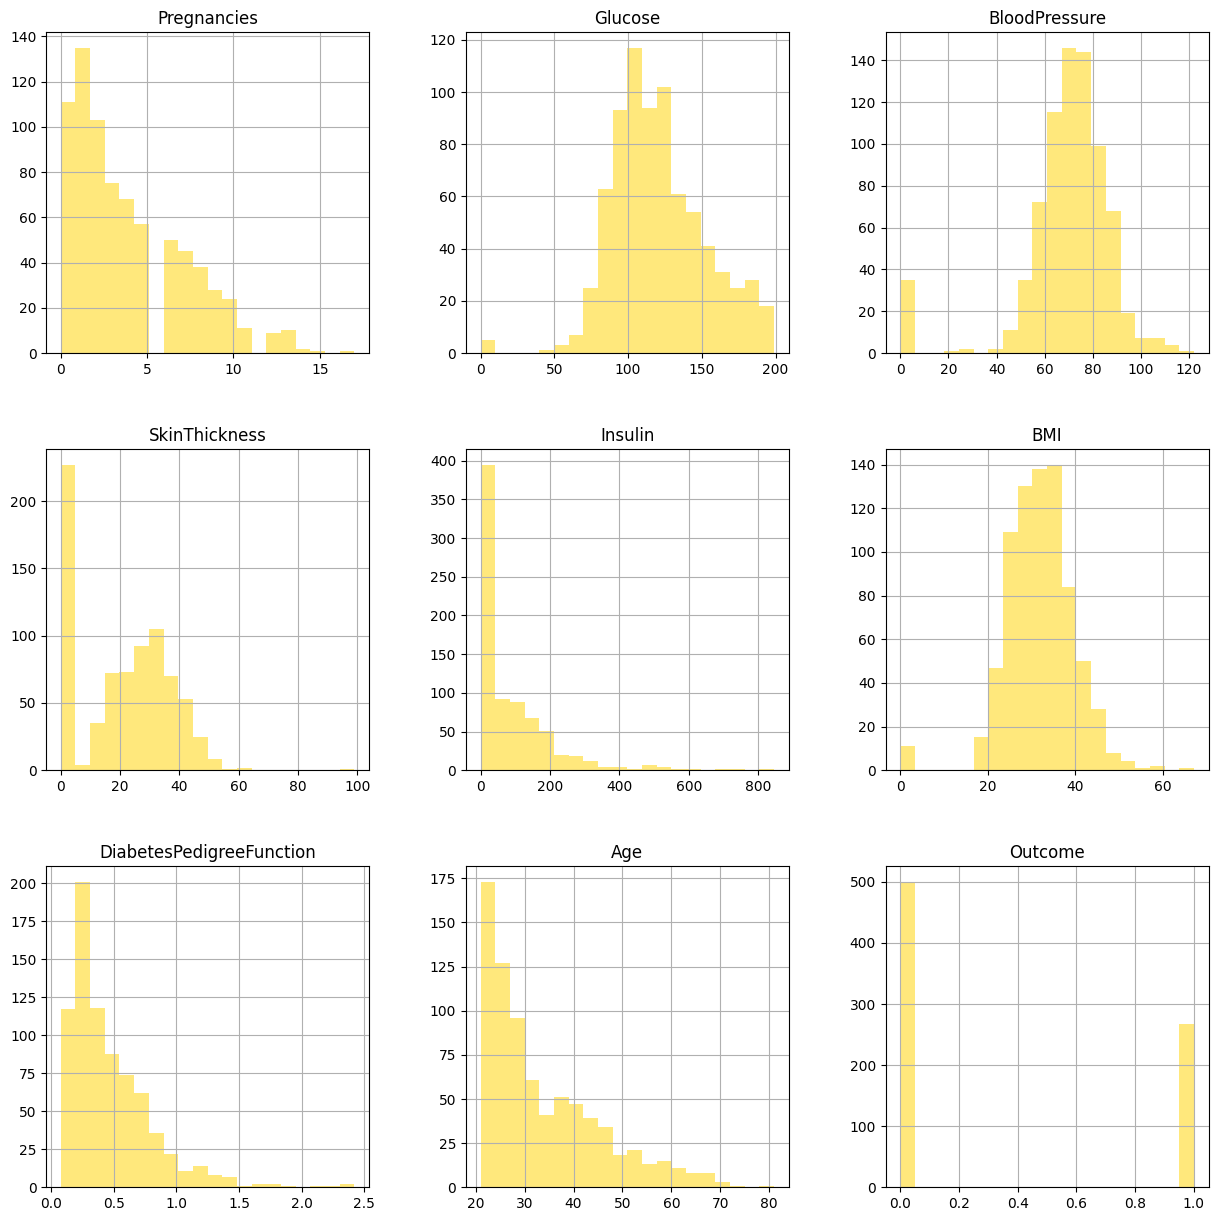

In [8]:
df.hist(bins=20, figsize=(15, 15), color='#FFE87C')
plt.show()

#### Pregnancies Column

#### Preganancies Distribution

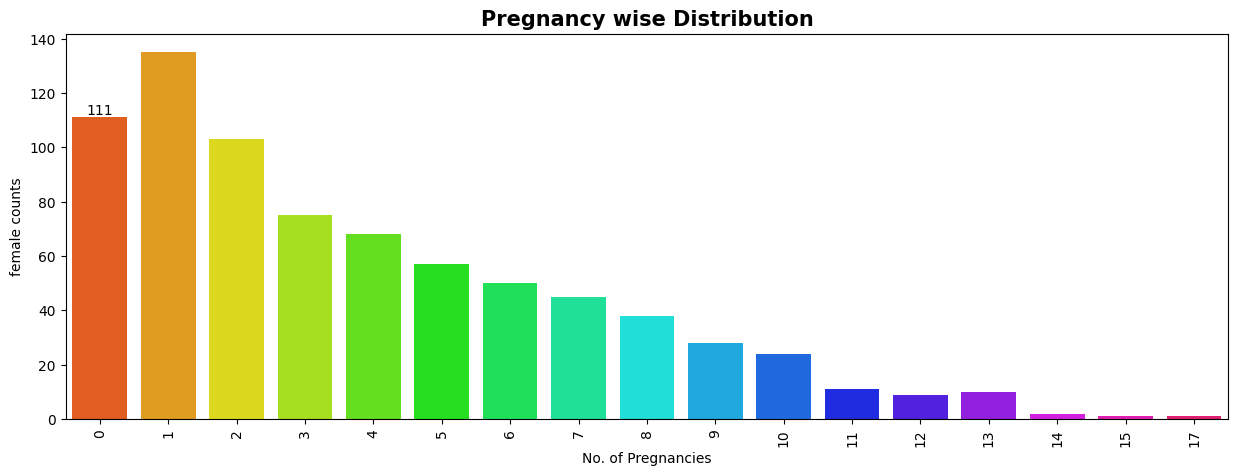

In [9]:
plt.figure(figsize=(15,5))
counts = df["Pregnancies"].value_counts().sort_values(ascending=False)
ax = sns.barplot(x=counts.index, y=counts.values,palette="hsv")
ax.bar_label(ax.containers[0], )
plt.xlabel("No. of Pregnancies")
plt.ylabel("female counts")
plt.title("Pregnancy wise Distribution",fontweight="black", fontsize=15)
plt.xticks(rotation=90)
plt.show()

### Observation :

1. Most of the females are having 1 pregnancies.
2. There are many females having 0 pregnancies.
3. The female count is decreasing as the number of pregnancies increases.

#### Pregnant females distribution diabetes wise

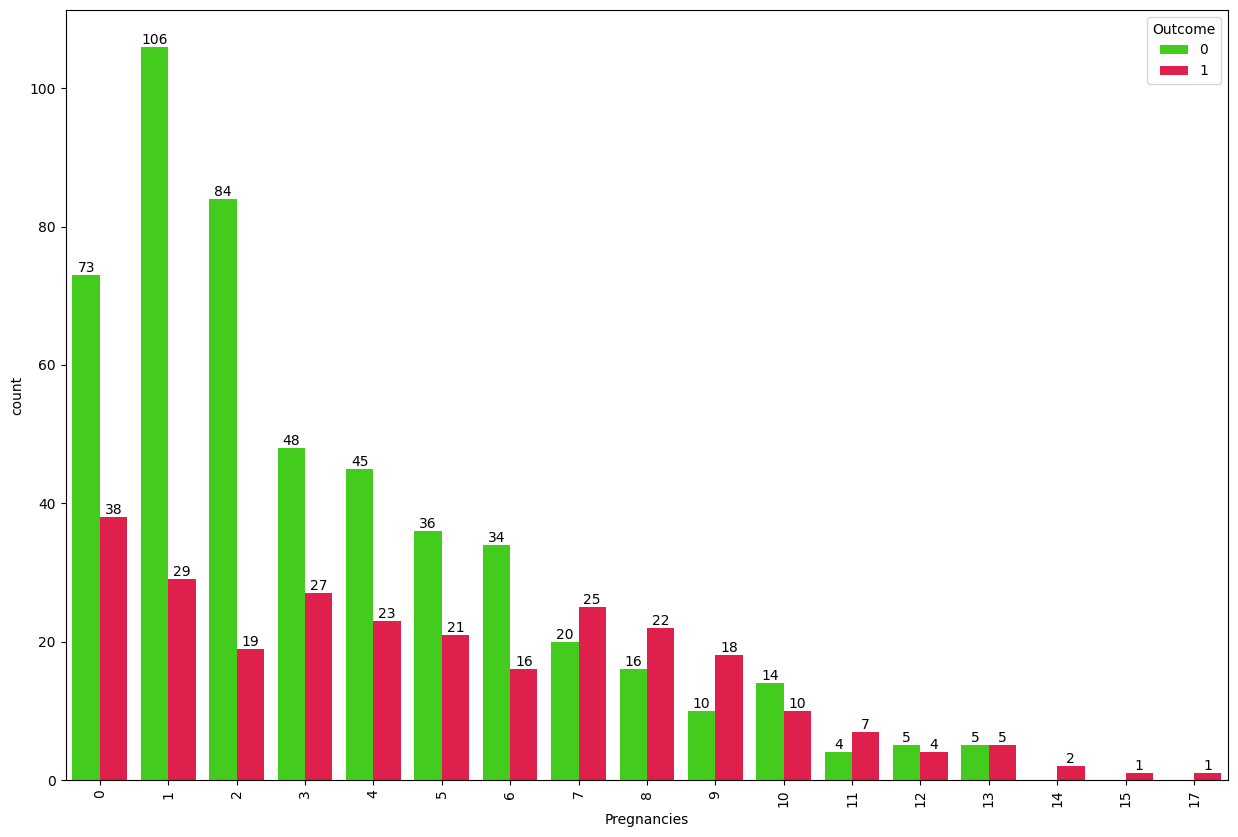

In [10]:
from pandas._libs.tslibs.offsets import prefix_mapping
plt.figure(figsize=(15,10))
preg_count = sns.countplot(x='Pregnancies', data=df, palette="prism",hue='Outcome')
# Display labels on the bars
for container in preg_count.containers:
    preg_count.bar_label(container)
plt.xticks(rotation=90)
plt.show()

### Observation:

1. Most of the females are non-diabetic.
2. The females are having less number of pregnancies are more non-diabetic , for example pregnancies range from 0 to 6.
3. The females are having more number of pregnancies are more diabetic , for example pregnancies range from 7, 8, 9, 11, 14, 15, 17.

#### Age Column

#### Age Distribution

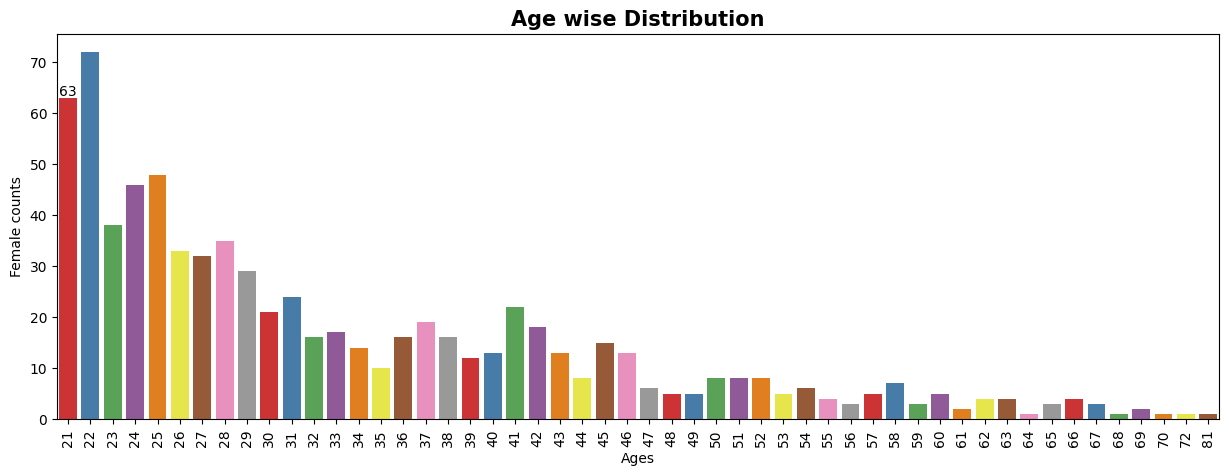

In [11]:
plt.figure(figsize=(15,5))
counts = df["Age"].value_counts().sort_values(ascending=False)
ax = sns.barplot(x=counts.index, y=counts.values,palette="Set1")
ax.bar_label(ax.containers[0], )
plt.xlabel("Ages")
plt.ylabel("Female counts")
plt.title("Age wise Distribution",fontweight="black", fontsize=15)
plt.xticks(rotation=90)
plt.show()

### Observation:

1. Most of the female ranges between 20 to 30 years old.
2. There are very few no. of femaleshaving high age category.

#### Age Distribution Diabetes Wise using Density Plot.

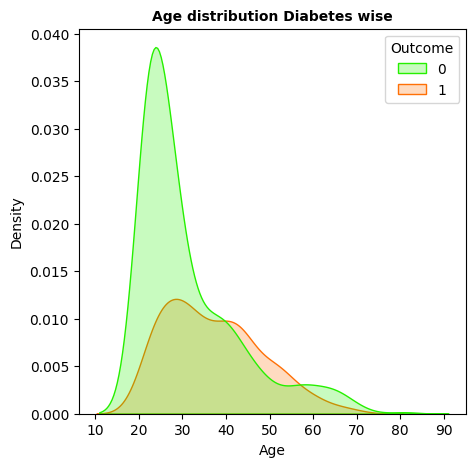

In [12]:
plt.figure(figsize=(5,5))
sns.kdeplot(x=df["Age"],hue=df["Outcome"],shade=True,palette="gist_ncar")
plt.title("Age distribution Diabetes wise",fontweight="black", fontsize=10)
plt.show()

### Observation:

1. Patients with no diabetes are having high density.
2. Patients with diabetes are having low density.
3. Most of the Non Diabetic Patients ranges between 20 - 35 years old.
4. Most of the Diabetic Patients ranges between 25 - 45 years old.

#### The Relation Between Age and Other Features.

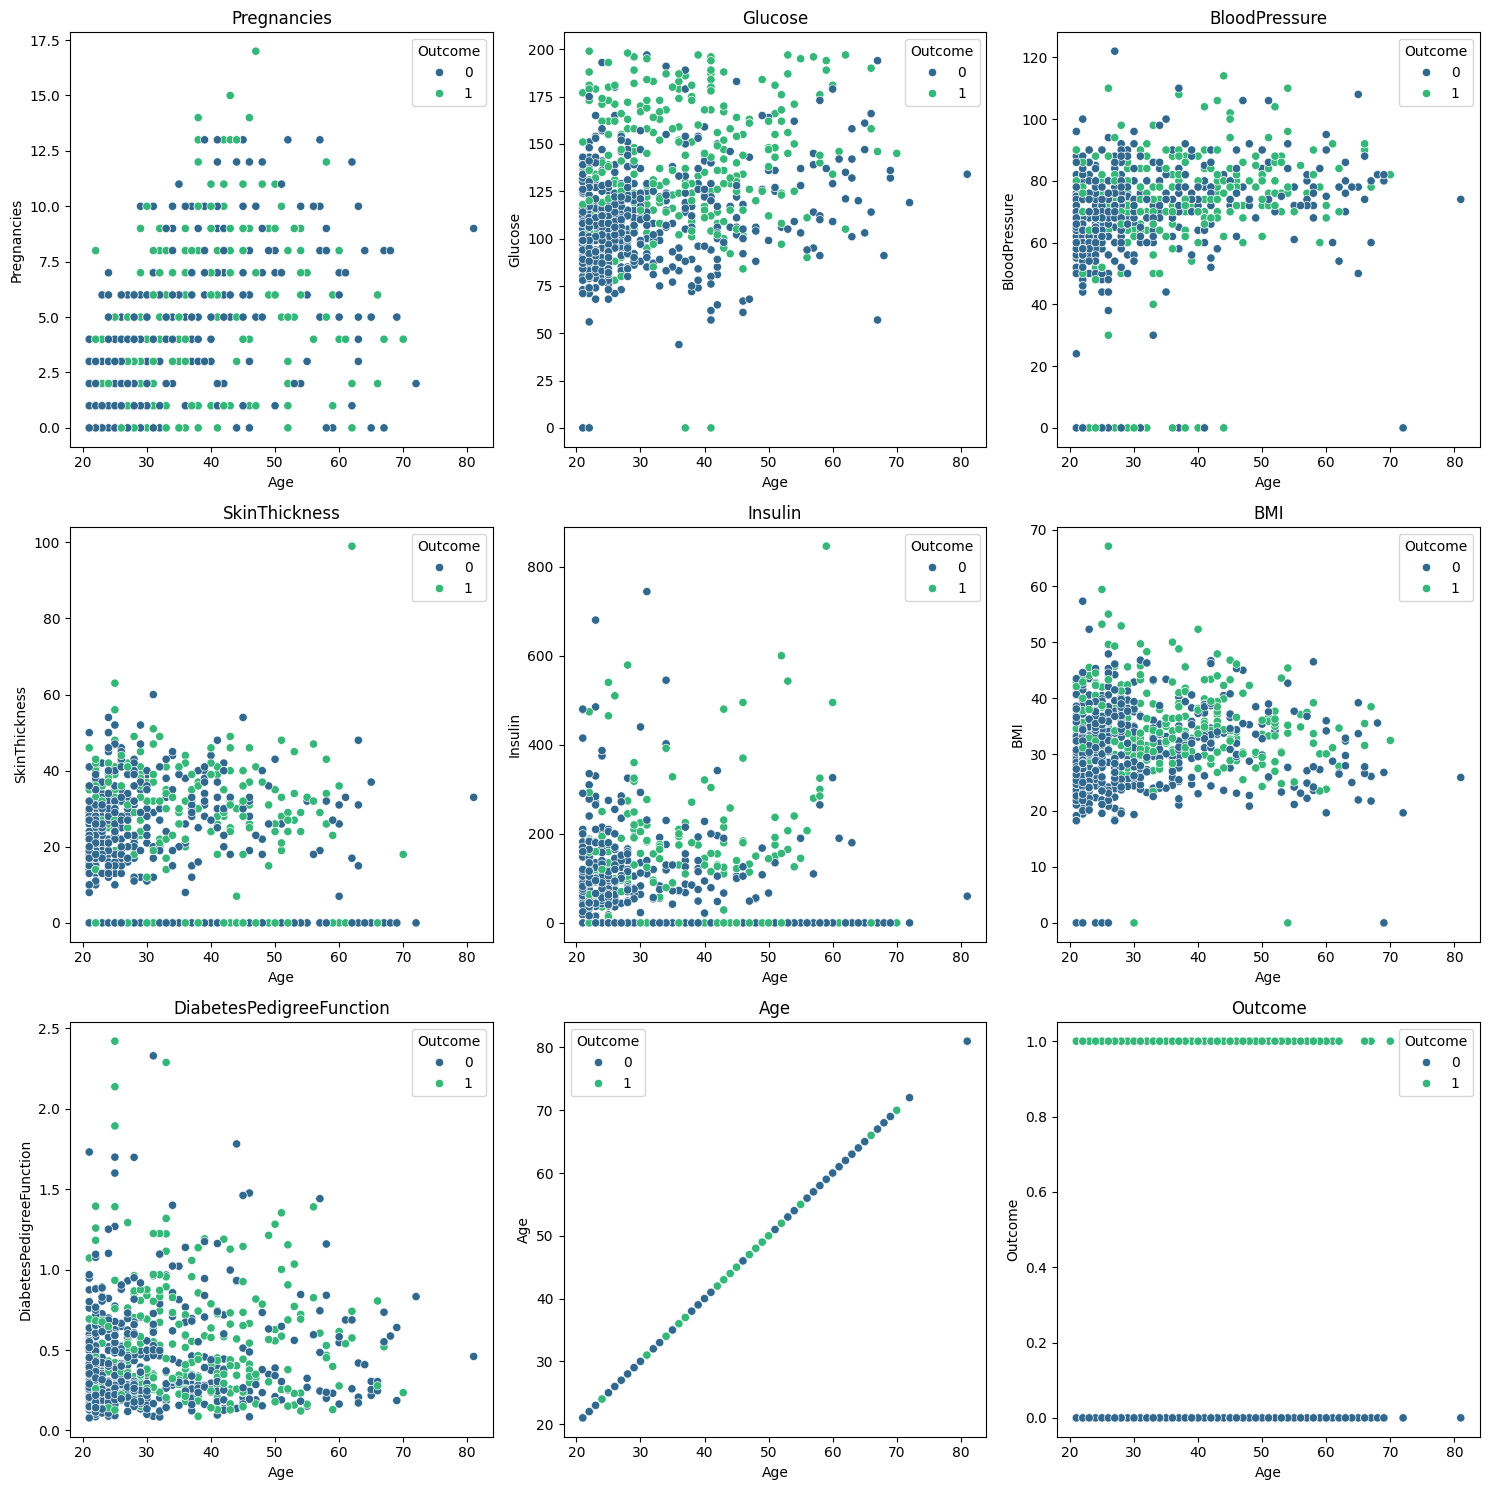

In [13]:
fig = plt.figure(figsize=(15,15))
for index,column in enumerate(list(df.columns[0:10])):
    plt.subplot(3,3,index+1)
    sns.scatterplot(y = df.loc[:, column], x = df["Age"], hue=df["Outcome"],palette='viridis')
    plt.title(column, size = 12)
fig.tight_layout()

#### Changes in some features over Age

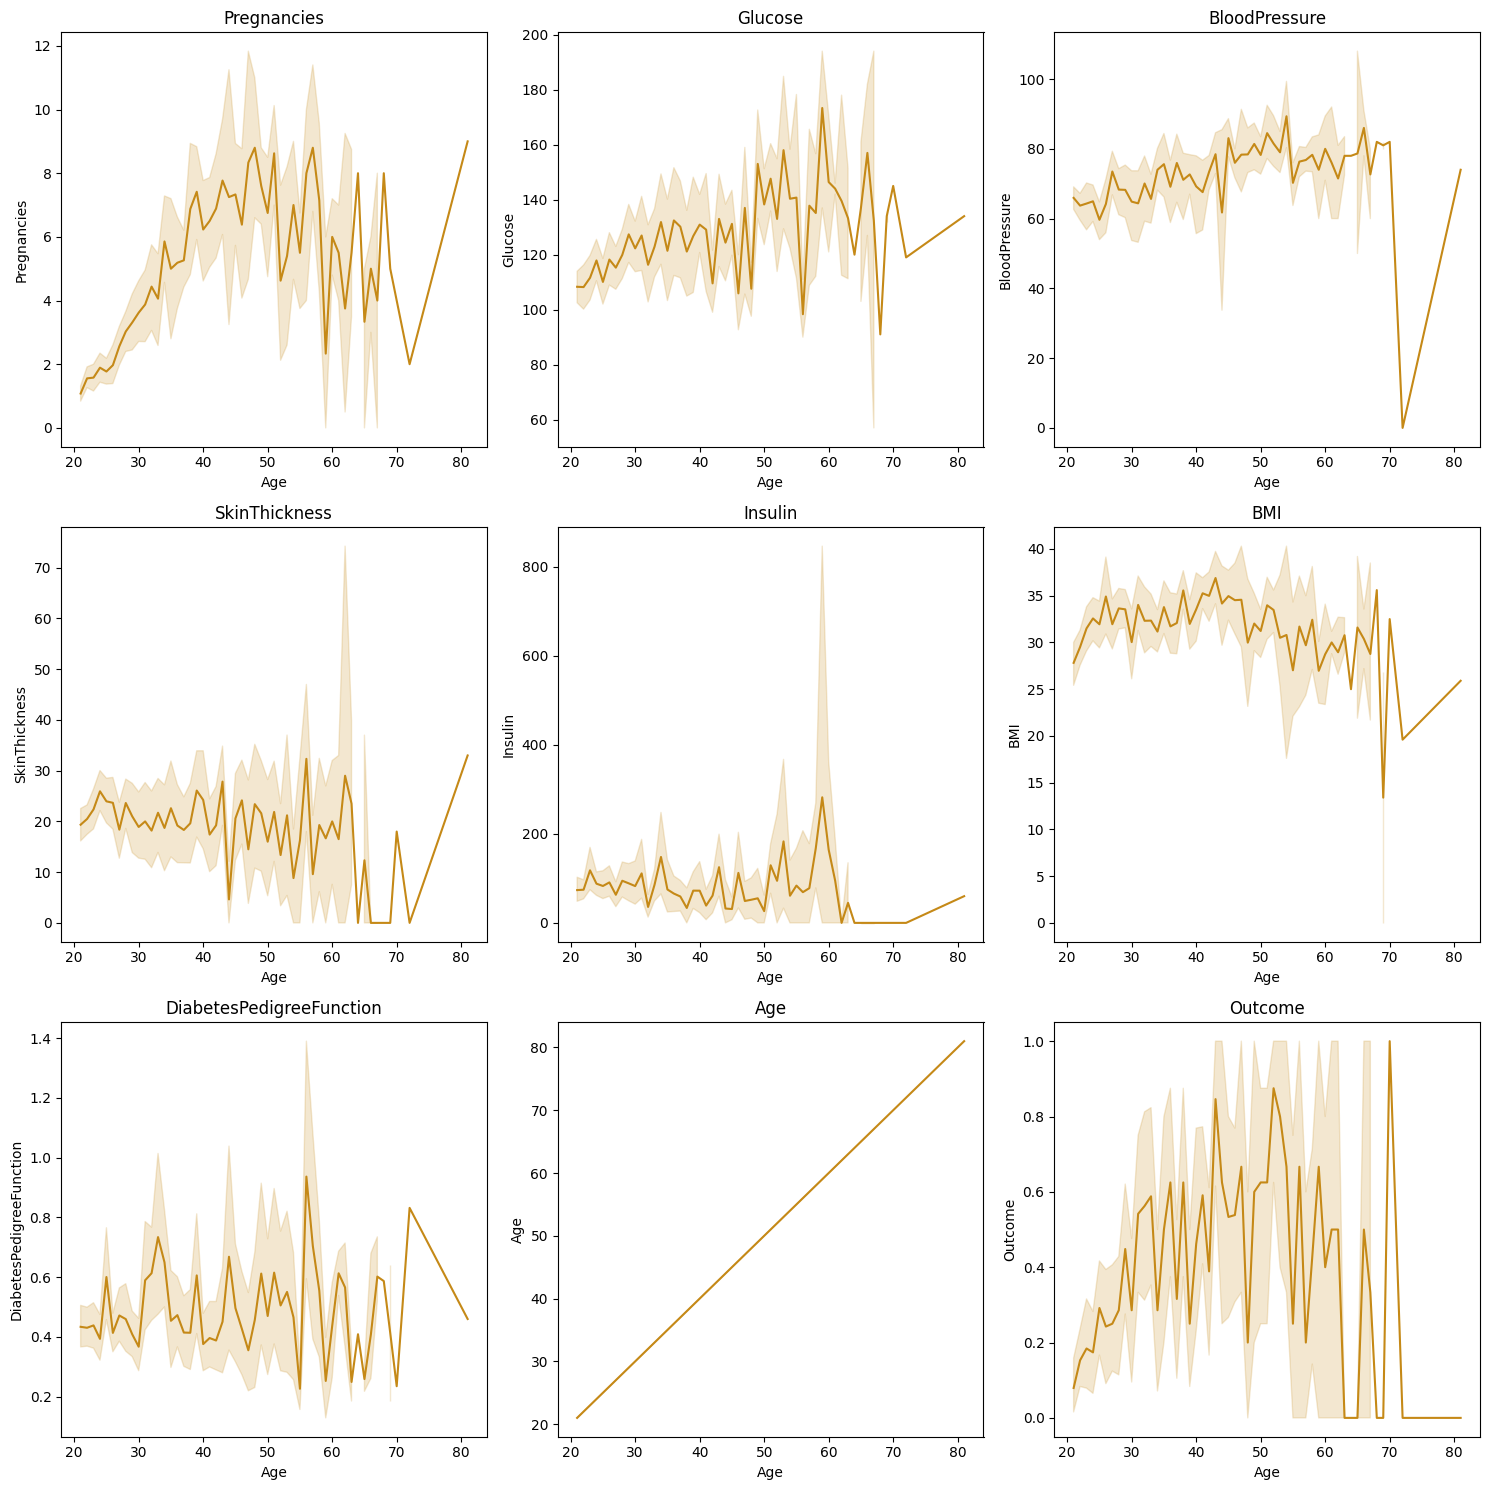

In [14]:
fig = plt.figure(figsize=(15,15))
for index,column in enumerate(list(df.columns[0:10])):
    plt.subplot(3,3,index+1)
    sns.lineplot(y = df.loc[:, column], x = df["Age"],color='#C58917')
    plt.title(column, size = 12)
fig.tight_layout()

#### Plotting Target Variable (Outcome)

In [15]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


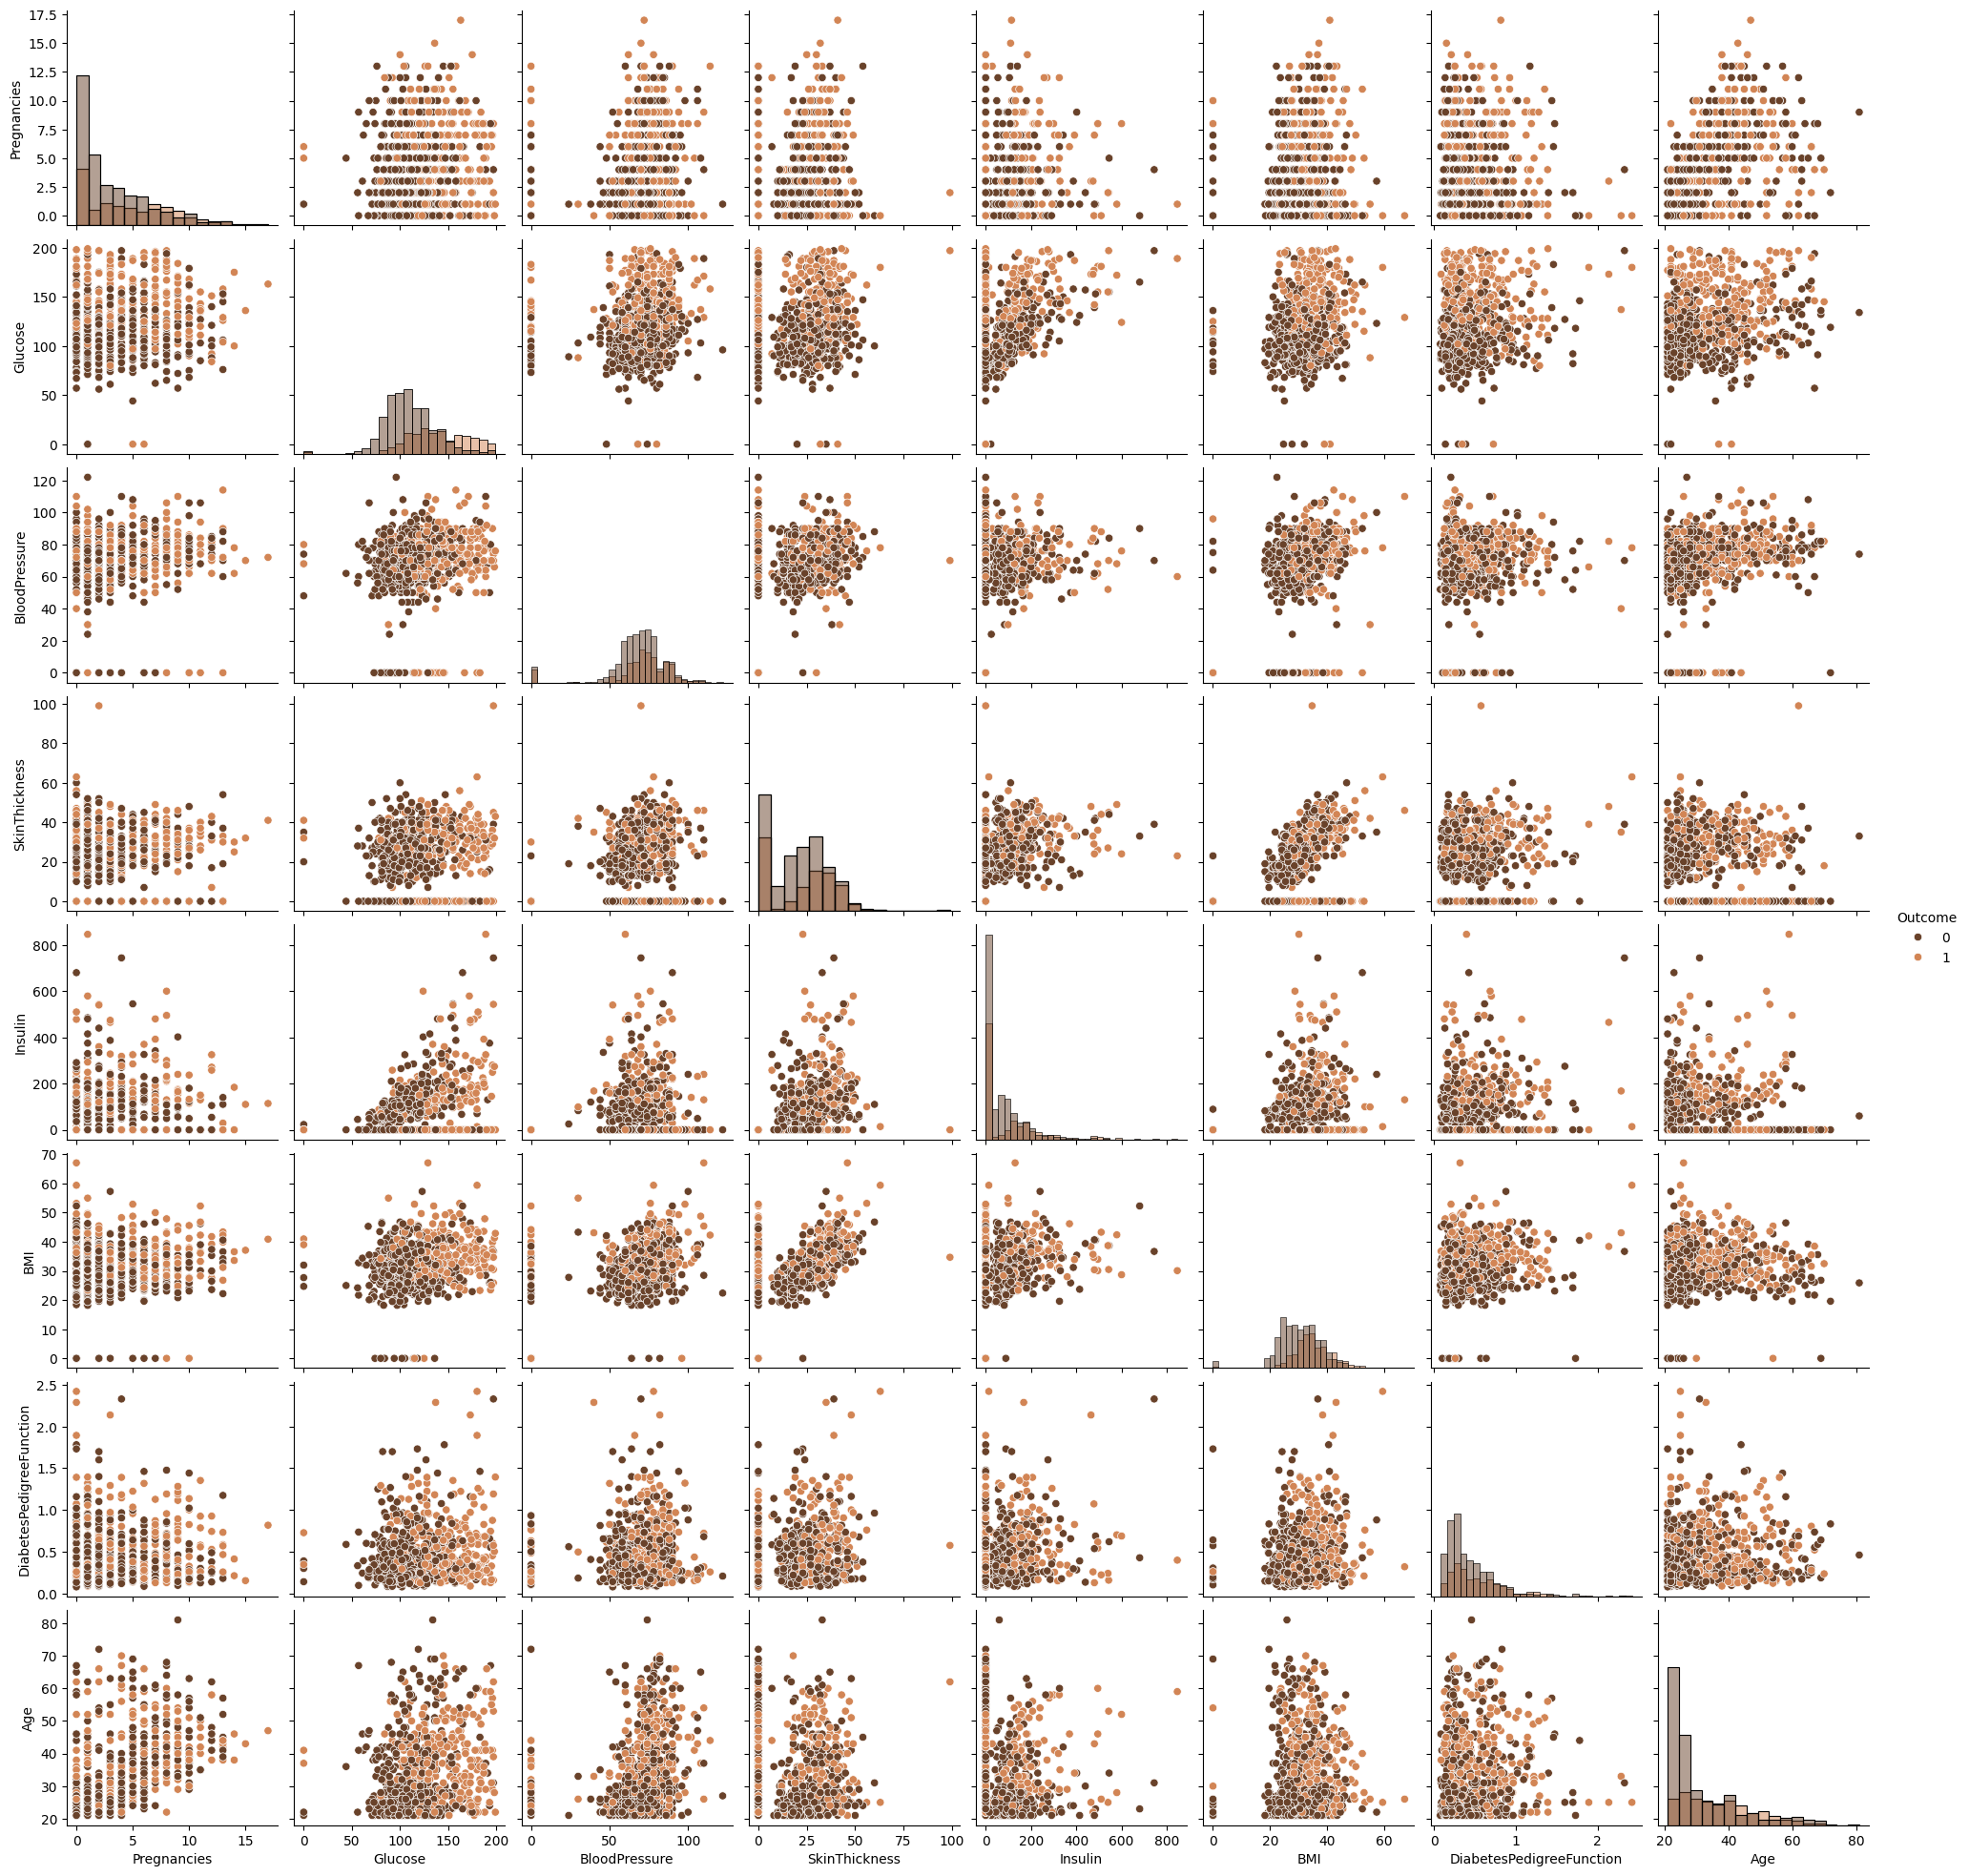

In [16]:
# plotting pairplot
sns.pairplot(df, hue='Outcome', diag_kind='hist',palette='copper')
plt.show()

#### Selecting the Dependent and Independent Features

In [17]:
x = df.drop('Outcome',axis=1) # x denotes independent features
y = df['Outcome']             # y denotes dependent variable
print(type(x))
print(type(y))
print(x.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(768, 8)
(768,)


In [20]:
x.shape , y.shape

((768, 8), (768,))

In [22]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [21]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

#### Preparing the data for model training

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [25]:
# Normalising the data before training help us to achieve stable and fast training of the model.
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
x_train = norm.fit_transform(x_train)
x_test = norm.transform(x_test)

In [26]:
print(x_train)

[[0.41176471 0.75757576 0.63934426 ... 0.52459016 0.26216909 0.55      ]
 [0.23529412 0.48989899 0.49180328 ... 0.42026826 0.1558497  0.01666667]
 [0.         0.83333333 0.73770492 ... 0.77943368 0.14901793 0.03333333]
 ...
 [0.23529412 0.47474747 0.53278689 ... 0.3681073  0.02988898 0.        ]
 [0.64705882 0.42929293 0.60655738 ... 0.4485842  0.09479078 0.23333333]
 [0.29411765 0.68686869 0.67213115 ... 0.         0.23996584 0.8       ]]


In [27]:
print(x_test)

[[0.05882353 1.00505051 0.62295082 ... 0.63934426 0.56191289 0.01666667]
 [0.11764706 0.54040404 0.60655738 ... 0.50074516 0.13919727 0.03333333]
 [0.23529412 0.38383838 0.50819672 ... 0.50670641 0.13364646 0.06666667]
 ...
 [0.23529412 0.71717172 0.70491803 ... 0.6557377  0.24210077 0.01666667]
 [0.17647059 0.58585859 0.60655738 ... 0.39195231 0.01238258 0.05      ]
 [0.05882353 0.54040404 0.59016393 ... 0.45901639 0.31725021 0.05      ]]


In [28]:
# Importing Libraries
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.metrics import roc_auc_score,roc_curve, auc

In [29]:
def eval_model(model, model_name, x_test, y_test, y_pred):
    print(f"--- {model_name} Evaluation ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


### Model Selection

#### 1. Logistic Regression

In [30]:
# importing Logistic Regression library
from sklearn.linear_model import LogisticRegression

# Building the LogReg model
lr = LogisticRegression()
lr.fit(x_train,y_train)

# Generating prediction
ypred_lr= lr.predict(x_test)
print(ypred_lr)

# Evaluate the model - classification Report, Accuaracy Score
eval_model(lr, 'Logistic Regression', x_test, y_test, ypred_lr)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0]
--- Logistic Regression Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       107
           1       0.77      0.57      0.66        47

    accuracy                           0.82       154
   macro avg       0.80      0.75      0.77       154
weighted avg       0.81      0.82      0.81       154

Accuracy: 0.8181818181818182


[[99  8]
 [20 27]]


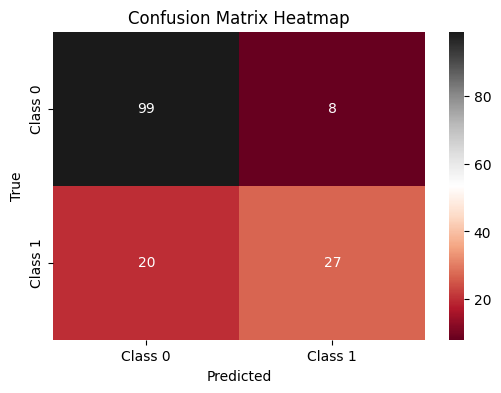

In [31]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_lr)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 2. KNN Classifier

In [32]:
# importing KNN library
from sklearn.neighbors import KNeighborsClassifier

# Building the KNN Classifier Model
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

# Generating prediction
ypred_knn= knn.predict(x_test)
print(ypred_knn)

# Evaluate the model - classification Report, Accuaracy Score
eval_model(knn, 'KNN Classifier', x_test, y_test, ypred_knn)

[1 0 0 1 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 0 0 0 0 1
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 0 0]
--- KNN Classifier Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       107
           1       0.66      0.57      0.61        47

    accuracy                           0.78       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.77      0.78      0.77       154

Accuracy: 0.7792207792207793


[[93 14]
 [20 27]]


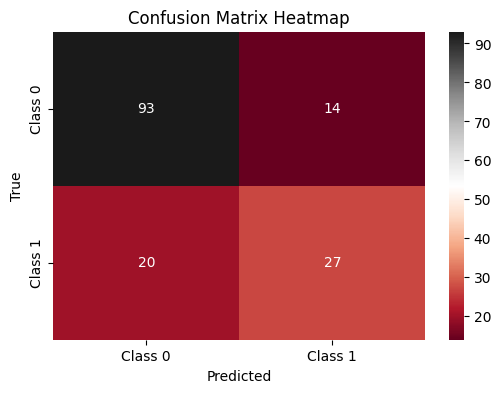

In [33]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_knn)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 3. Decision Tree Classifier

In [34]:
# importing Decision Tree library
from sklearn.tree import DecisionTreeClassifier

# Building the Decition Tree model
dt = DecisionTreeClassifier(criterion='gini')
dt.fit(x_train,y_train)

# Generating the predictions
ypred_dt = dt.predict(x_test)
print(ypred_dt)

# Evaluate the model - classification Report, Accuaracy Score
eval_model(dt,'Decision Tree Classifier',x_test,y_test,ypred_dt)

[1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0
 0 1 1 0 0 0 1 1 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0]
--- Decision Tree Classifier Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       107
           1       0.68      0.77      0.72        47

    accuracy                           0.82       154
   macro avg       0.79      0.80      0.79       154
weighted avg       0.83      0.82      0.82       154

Accuracy: 0.8181818181818182


[[90 17]
 [11 36]]


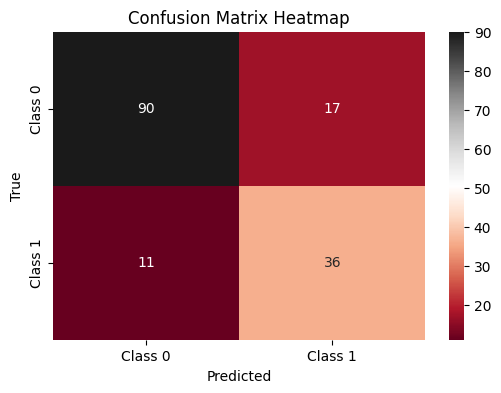

In [35]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_dt)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 4. Random Forest Classifier

In [36]:
# Import Random Forest library
from sklearn.ensemble import RandomForestClassifier

# Building the RF Model
rf = RandomForestClassifier(n_estimators=80)
rf.fit(x_train,y_train)

# Generating the predictions
ypred_rf = rf.predict(x_test)
print(ypred_rf)

# Evaluate the model - classification Report, Accuaracy Score
eval_model(rf,'Random Forest',x_test,y_test,ypred_rf)

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 0 0]
--- Random Forest Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154

Accuracy: 0.8051948051948052


[[93 14]
 [16 31]]


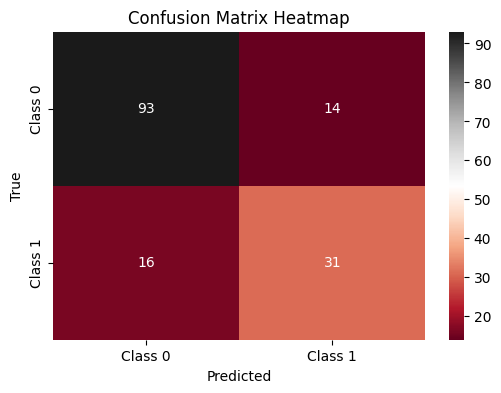

In [37]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_rf)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 5. Support Vector Machine

In [38]:
# Import SVM library
from sklearn.svm import SVC

# Building the SVM Model
svm = SVC()
svm.fit(x_train, y_train)

# Generating the predictions
ypred_svm = svm.predict(x_test)
print(ypred_svm)

# Evaluate the model - classification Report, Accuracy Score
eval_model(svm, 'SVM', x_test, y_test, ypred_svm)


[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0]
--- SVM Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       107
           1       0.72      0.55      0.63        47

    accuracy                           0.80       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.79      0.80      0.79       154

Accuracy: 0.7987012987012987


[[97 10]
 [21 26]]


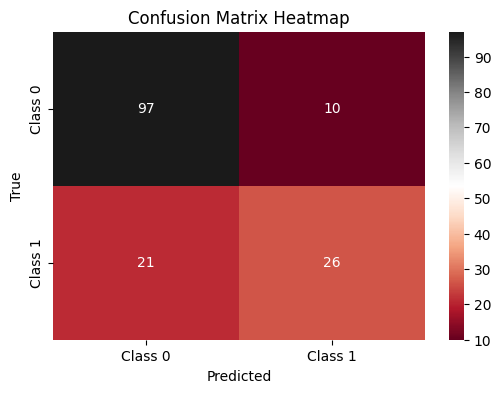

In [39]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_svm)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# 6. Naive Bayes

In [40]:
# Import Naive Bayes library
from sklearn.naive_bayes import GaussianNB

# Building the Naive Bayes Model
nb = GaussianNB()
nb.fit(x_train, y_train)

# Generating the predictions
ypred_nb = nb.predict(x_test)
print(ypred_nb)

# Evaluate the model - classification Report, Accuracy Score
eval_model(nb, 'Naive Bayes', x_test, y_test, ypred_nb)

[1 0 0 1 0 0 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
--- Naive Bayes Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       107
           1       0.67      0.62      0.64        47

    accuracy                           0.79       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.79      0.79      0.79       154

Accuracy: 0.7922077922077922


[[93 14]
 [18 29]]


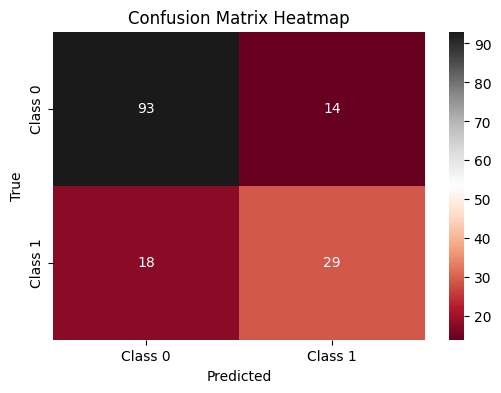

In [41]:
# Create the confusion matrix heatmap
cm = confusion_matrix(y_test, ypred_nb)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy', xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Dataframe for showing the best model

In [42]:
best_model = pd.DataFrame({
    'Model': ['Logistic Regression','KNN Classifier','Decision Tree Classifier' ,'Random Forest Classifier','SVM Classifier','Naive Bayes Classifier'],
    'Accuracy Score': [accuracy_score(y_test, ypred_lr),accuracy_score(y_test, ypred_knn),accuracy_score(y_test, ypred_dt),accuracy_score(y_test, ypred_rf),accuracy_score(y_test, ypred_svm),accuracy_score(y_test, ypred_nb)]})
best_model_df = best_model.sort_values(by='Accuracy Score', ascending=False)
best_model_df

,Model,Accuracy Score
0,Logistic Regression,0.818182
2,Decision Tree Classifier,0.818182
3,Random Forest Classifier,0.805195
4,SVM Classifier,0.798701
5,Naive Bayes Classifier,0.792208
1,KNN Classifier,0.779221


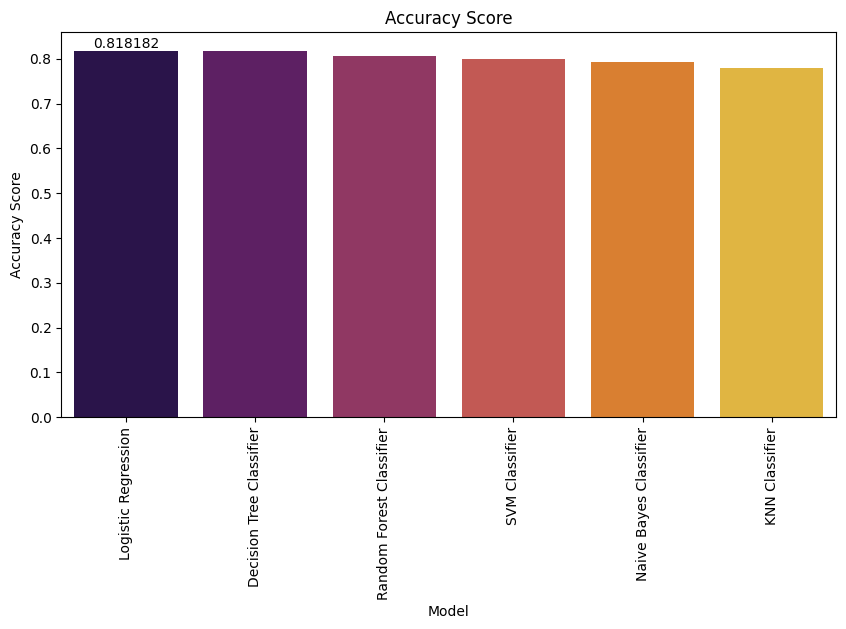

In [43]:
# Plotting the result
plt.figure(figsize=(10,5))
ax = sns.barplot(x='Model',y='Accuracy Score',data=best_model_df,palette='inferno')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.title('Accuracy Score')
plt.show()

#### Predictions on best model

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       107
           1       0.77      0.57      0.66        47

    accuracy                           0.82       154
   macro avg       0.80      0.75      0.77       154
weighted avg       0.81      0.82      0.81       154

ROC-AUC Score: 0.8680


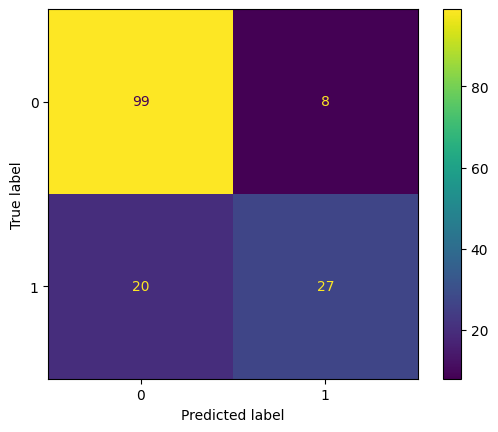

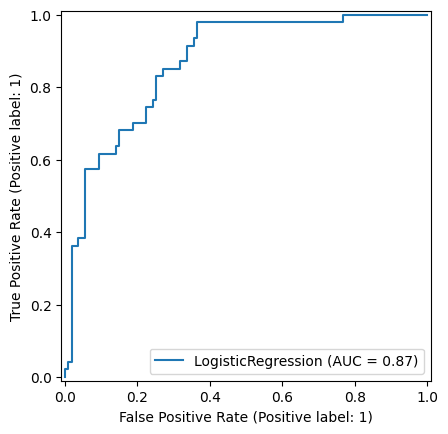

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# Make predictions
y_pred = lr.predict(x_test)
y_proba = lr.predict_proba(x_test)[:, 1]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
RocCurveDisplay.from_estimator(lr, x_test, y_test)


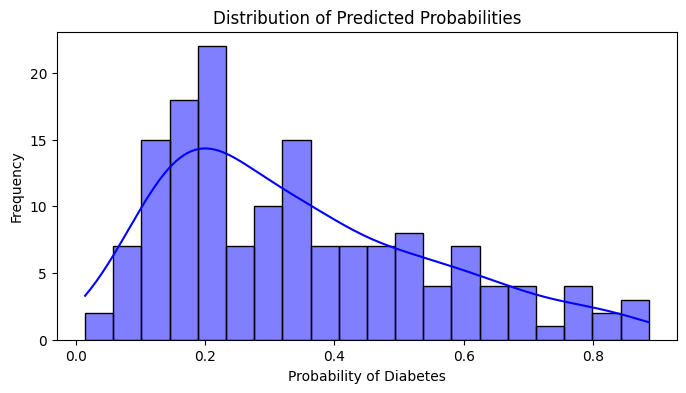

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize prediction probabilities
plt.figure(figsize=(8, 4))
sns.histplot(y_proba, bins=20, kde=True, color='blue')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability of Diabetes")
plt.ylabel("Frequency")
plt.show()

In [50]:
# Make sure you use the correct casing
results_df = pd.DataFrame(x_test.copy())  # Ensure it's a DataFrame

# Add columns directly
results_df["Actual"] = y_test  # No need for .values if it's a Series
results_df["Predicted"] = y_pred
results_df["Probability"] = y_proba

# Preview
results_df.head()


,0,1,2,3,4,5,6,7,Actual,Predicted,Probability
0,0.058824,1.005051,0.622951,0.434343,0.000000,0.639344,0.561913,0.016667,NaN,1,0.849897
1,0.117647,0.540404,0.606557,0.303030,0.118203,0.500745,0.139197,0.033333,0.0,0,0.214002
2,0.235294,0.383838,0.508197,0.000000,0.000000,0.506706,0.133646,0.066667,1.0,0,0.135412
3,0.294118,0.838384,0.590164,0.191919,0.206856,0.384501,0.217336,0.500000,NaN,1,0.614718
4,0.000000,0.560606,0.532787,0.000000,0.000000,0.366617,0.248506,0.166667,NaN,0,0.180365


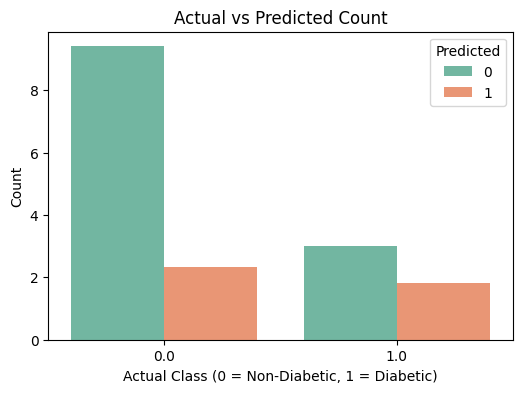

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=results_df, x="Actual", hue="Predicted", palette="Set2")
plt.title("Actual vs Predicted Count")
plt.xlabel("Actual Class (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.legend(title="Predicted")
plt.show()

In [55]:
# False Positives (Predicted diabetic, actually not)
false_positives = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]

# False Negatives (Predicted not diabetic, actually diabetic)
false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))


False Positives: 3
False Negatives: 6


In [51]:
results_df.to_csv("prediction_results.csv", index=False)

### Save the Best Model

In [56]:
import joblib

# Save model and scaler
joblib.dump(lr, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [57]:
joblib.dump(norm, 'scaler.pkl')

['scaler.pkl']

In [58]:
sample = np.array([[2, 120, 70, 28, 80, 25.0, 0.5, 30]])
sample_scaled = norm.transform(sample)
prediction = lr.predict(sample_scaled)
print("Diabetes Prediction (1=Yes, 0=No):", prediction[0])


Diabetes Prediction (1=Yes, 0=No): 0


### Conclusion

🔍 Objective
The goal of this project was to build a machine learning model that predicts whether a person has diabetes based on diagnostic medical measurements and deploy it as an interactive web application using Streamlit. This enables real-time, accessible predictions for end users without requiring deep technical knowledge.

| Model                    | Accuracy  |
| ------------------------ | --------- |
| Logistic Regression      | **0.818** |
| Decision Tree Classifier | **0.818** |
| Random Forest Classifier | 0.805     |
| SVM Classifier           | 0.799     |
| Naive Bayes Classifier   | 0.792     |
| KNN Classifier           | 0.779     |

-> Best Models: Logistic Regression and Decision Tree Classifier (tied)


#### Web App Deployment Using Streamlit
Created an interactive web app (app.py) to:

- Accept user inputs for medical attribute
- Predict diabetic status in real-time using trained model
- Display a clear, readable output: Diabetic / Not Diabetic
- Show a model comparison table for transparency
- User-friendly UI with real-time feedback.

#### Outcomes & Learnings
- Completed full ML workflow from data to deployment

- Gained practical experience with:
      - Model comparison and selection
      - Visualizing ML performance

- Streamlit for interactive deployment

- Built an end-to-end diabetes prediction system

